# Banknote Authentication Classification
Decision Tree vs Random Forest with GridSearchCV

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [5]:
df = pd.read_csv('/content/data_banknote_authentication.csv')
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [7]:

print(df.info())
print(df.describe())
print(df['Class'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None
       Variance_Wavelet  Skewness_Wavelet  Curtosis_Wavelet  Image_Entropy  \
count       1372.000000       1372.000000       1372.000000    1372.000000   
mean           0.433735          1.922353          1.397627      -1.191657   
std            2.842763          5.869047          4.310030       2.101013   
min           -7.042100        -13.773100         -5.286100      -8.548200   
25%           -1.773000         -1.708200         -1.574975      -2.413450   
50%            0.496180          2.319650

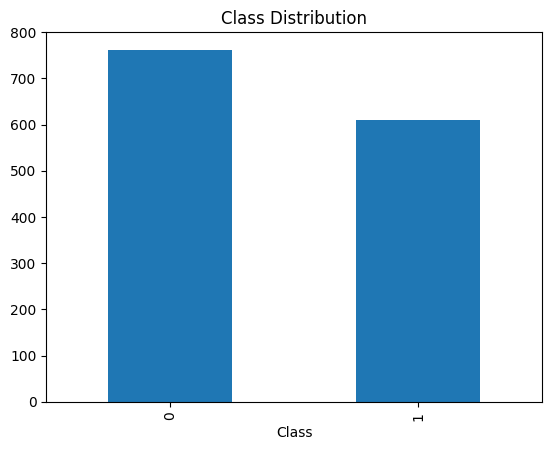

In [9]:

df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()


In [11]:

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:

dt = DecisionTreeClassifier()

dt_params = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.9781818181818182
[[147   1]
 [  5 122]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       148
           1       0.99      0.96      0.98       127

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275



In [13]:

rf = RandomForestClassifier()

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9927272727272727
[[148   0]
 [  2 125]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       148
           1       1.00      0.98      0.99       127

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



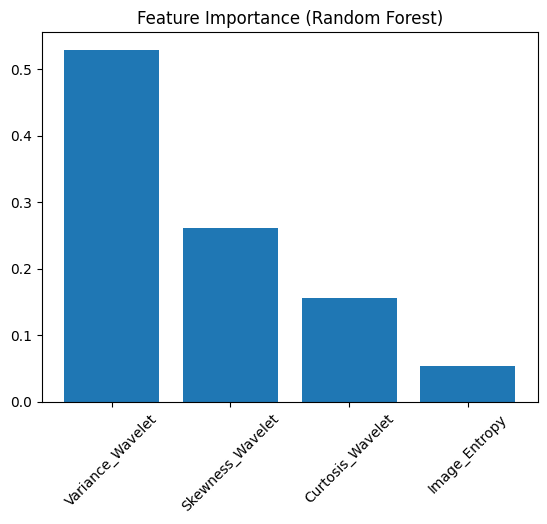

In [14]:

importances = rf_best.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xticks(rotation=45)
plt.show()



## Summary

- Decision Tree and Random Forest models were trained and optimized using GridSearchCV.
- Random Forest generally provides better performance due to ensemble learning.
- Feature importance shows which variables contribute most to classification.
- The dataset is well-structured and classification performance is typically high.

### Conclusion:
Random Forest is the preferred model for this task due to higher accuracy and robustness.
